# EDA (Exploratory Data Analytics)

**Esta EDA funciona para descubrir patrones y problemas iniciales:**
- Resúmenes estadísticos.
- Visualizaciones iniciales para identificar tendencias o anomalías.
- Correlaciones entre variables.

In [199]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

In [200]:
ruta = os.path.join('..', 'Data', 'TouristAccommodationRaw02022026.csv')
df = pd.read_csv(ruta)


In [201]:
df.shape #para saber cuantas filas y columnas tiene el dataframe

(10000, 35)

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 10000 non-null  int64  
 1   name                         9997 non-null   object 
 2   description                  9862 non-null   object 
 3   host_id                      10000 non-null  int64  
 4   neighbourhood_name           10000 non-null  object 
 5   neighbourhood_district       6079 non-null   object 
 6   room_type                    10000 non-null  object 
 7   accommodates                 10000 non-null  int64  
 8   bathrooms                    9926 non-null   float64
 9   bedrooms                     9930 non-null   float64
 10  beds                         9955 non-null   float64
 11  amenities_list               9983 non-null   object 
 12  price                        9746 non-null   float64
 13  minimum_nights   

In [203]:
df.isna().sum().sort_values(ascending=False)


neighbourhood_district         3921
review_scores_value            2724
review_scores_location         2724
review_scores_checkin          2723
review_scores_accuracy         2718
review_scores_communication    2714
review_scores_cleanliness      2712
review_scores_rating           2709
last_review_date               2605
reviews_per_month              2604
first_review_date              2604
has_availability                550
price                           254
description                     138
bathrooms                        74
bedrooms                         70
beds                             45
amenities_list                   17
name                              3
apartment_id                      0
availability_90                   0
availability_30                   0
maximum_nights                    0
minimum_nights                    0
neighbourhood_name                0
host_id                           0
accommodates                      0
room_type                   

<Axes: xlabel='city'>

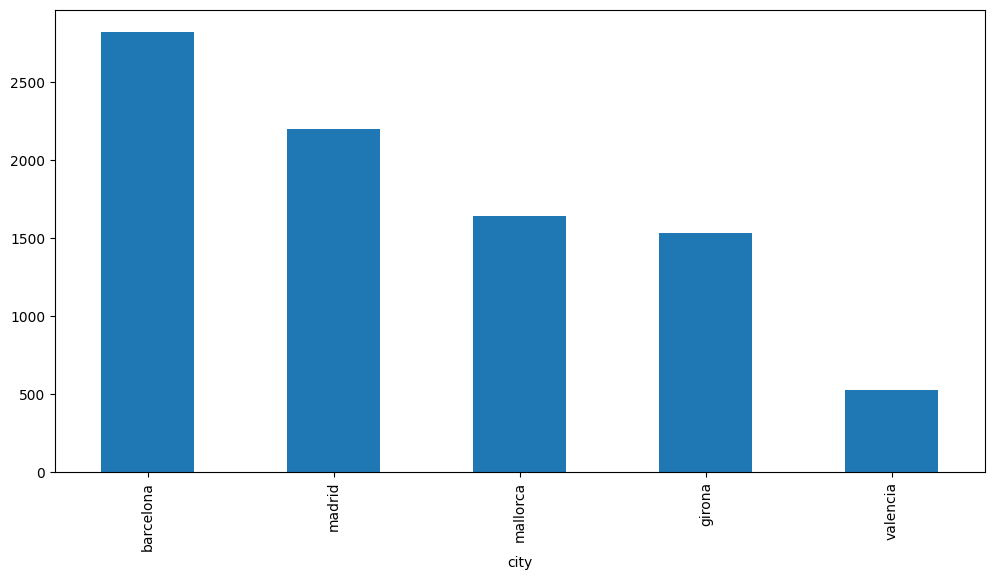

In [204]:
df['city'].value_counts().head(5).plot(kind='bar', figsize=(12,6))


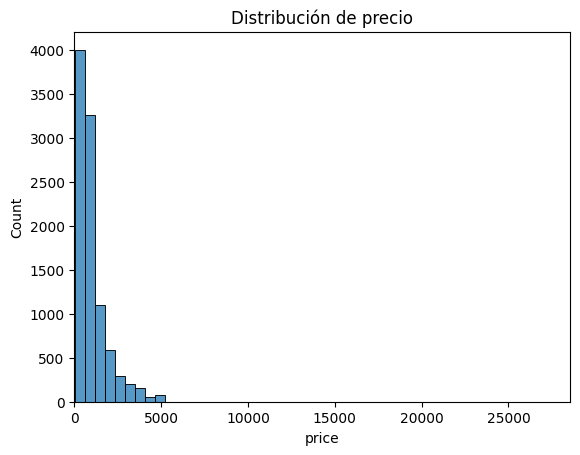

In [205]:
# distribución de precio (cortando extremos para ver mejor)
sns.histplot(df['price'], bins=50)
plt.xlim(0, df['price'].quantile(1))
plt.title('Distribución de precio')
plt.show()

In [206]:

# precios sospechosamente bajos o altos
df[df['price'] == 0].head()
df[df['price'] > df['price'].quantile(0.99)][['apartment_id', 'price', 'city', 'neighbourhood_name', 'room_type']].head()

,apartment_id,price,city,neighbourhood_name,room_type
25,157327,5000.0,girona,Forallac,Entire home/apt
92,507972,5000.0,barcelona,la Vila de Gr�cia,Entire home/apt
166,727788,4700.0,mallorca,Calvi�,Entire home/apt
298,1051645,4800.0,mallorca,Llucmajor,Entire home/apt
407,1351195,5000.0,girona,Tossa de Mar,Entire home/apt


In [207]:
# precio por persona
df['price_per_person'] = df['price'] / df['accommodates']

df['price_per_person'].describe()

count     9746.000000
mean       261.425816
std        262.677622
min          9.090909
25%        150.000000
50%        206.125000
75%        300.000000
max      12643.000000
Name: price_per_person, dtype: float64

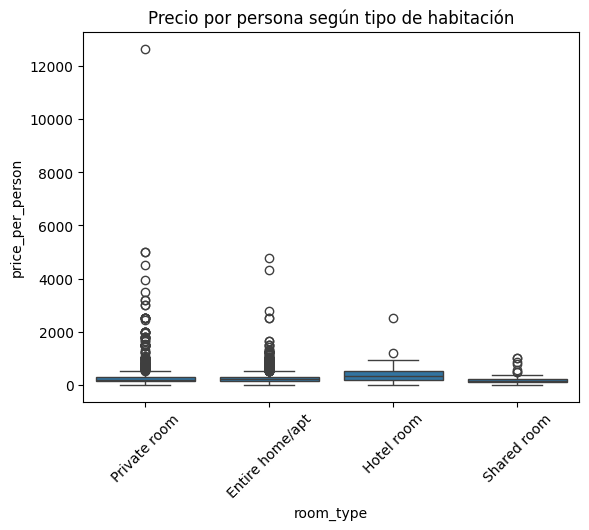

In [208]:
sns.boxplot(data=df, x='room_type', y='price_per_person')
plt.xticks(rotation=45)
plt.title('Precio por persona según tipo de habitación')
plt.show()

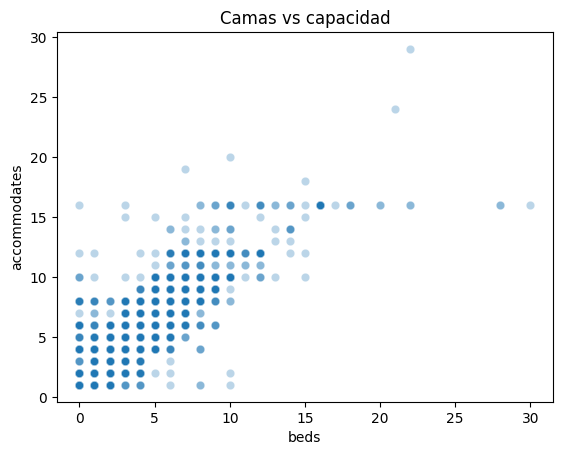

,apartment_id,beds,accommodates,bedrooms
120,602284,2.0,6,2.0
360,1199594,2.0,6,2.0
440,1492419,2.0,6,2.0
505,1830917,2.0,6,2.0
572,2202510,2.0,6,2.0


In [209]:
# relación accommodate s vs beds
sns.scatterplot(data=df, x='beds', y='accommodates', alpha=0.3)
plt.title('Camas vs capacidad')
plt.show()

# casos raros: mucha capacidad con pocas camas
df[(df['accommodates'] >= 6) & (df['beds'] <= 2)][['apartment_id','beds','accommodates','bedrooms']].head()


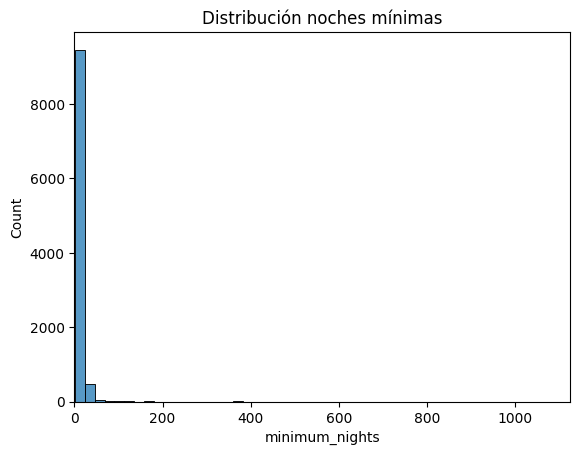

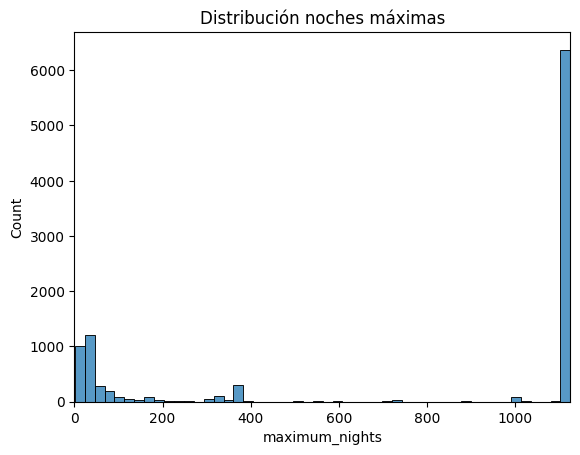

In [210]:
sns.histplot(df['minimum_nights'], bins=50)
plt.xlim(0, df['minimum_nights'].quantile(1))
plt.title('Distribución noches mínimas')
plt.show()

sns.histplot(df['maximum_nights'], bins=50)
plt.xlim(0, df['maximum_nights'].quantile(1))
plt.title('Distribución noches máximas')
plt.show()


In [211]:
# inconsistencias
df[df['minimum_nights'] > df['maximum_nights']].head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,price_per_person


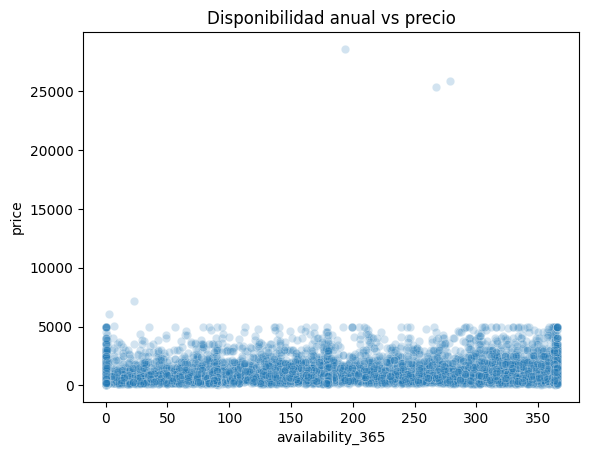

In [212]:
# disponibilidad vs precio
sns.scatterplot(data=df, x='availability_365', y='price', alpha=0.2)
plt.title('Disponibilidad anual vs precio')
plt.show()

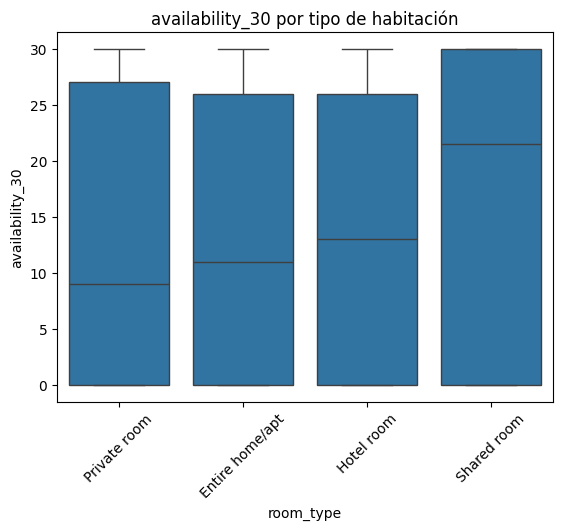

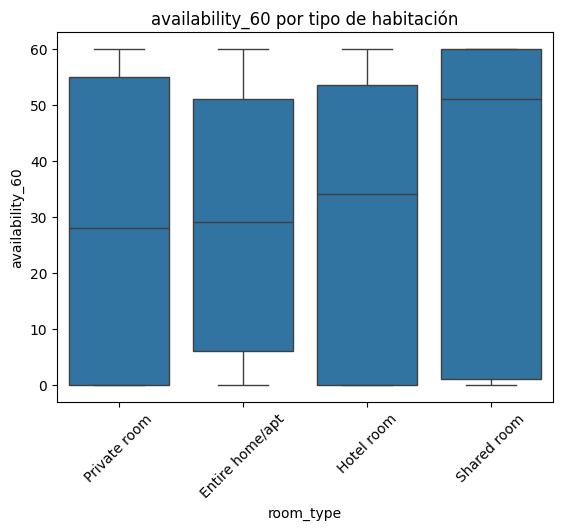

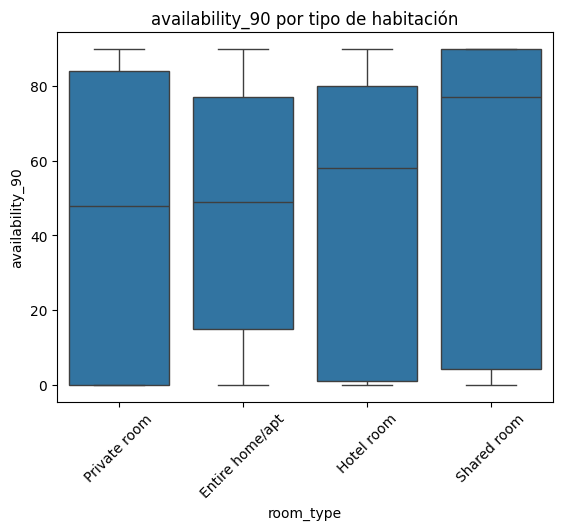

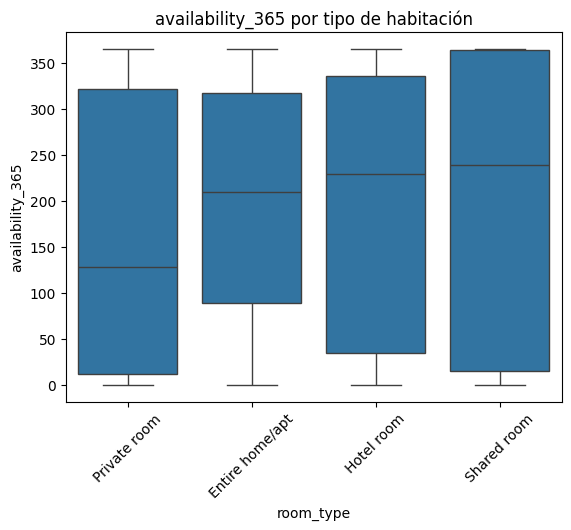

In [213]:
# disponibilidad por tipo de habitación
for col in ['availability_30','availability_60','availability_90','availability_365']:
    sns.boxplot(data=df, x='room_type', y=col)
    plt.xticks(rotation=45)
    plt.title(f'{col} por tipo de habitación')
    plt.show()


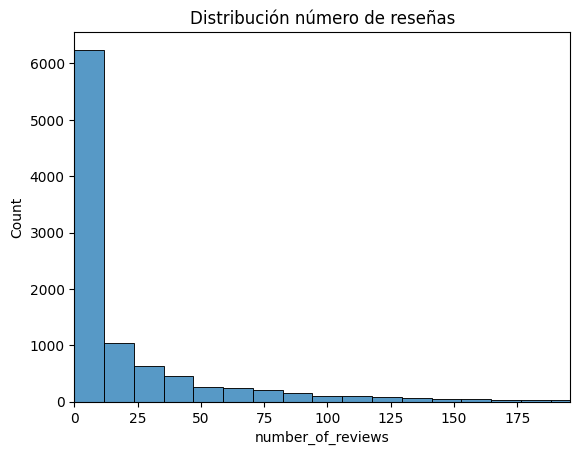

In [214]:
# distribución de numero de reseñas
sns.histplot(df['number_of_reviews'], bins=50)
plt.xlim(0, df['number_of_reviews'].quantile(0.98))
plt.title('Distribución número de reseñas')
plt.show()

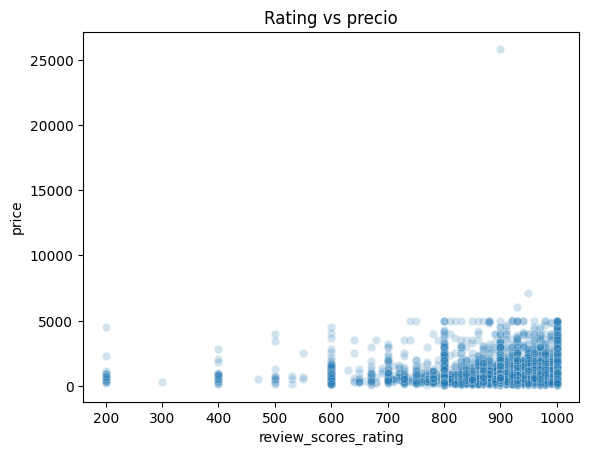

In [215]:
# rating vs precio
sns.scatterplot(data=df, x='review_scores_rating', y='price', alpha=0.2)
plt.title('Rating vs precio')
plt.show()

In [216]:
# ratings por barrio
rating_cols = [
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]
for c in rating_cols:
    df[c] = df[c] / 100
df.groupby('neighbourhood_district')[rating_cols].mean() \
  .round(2) \
  .sort_values('review_scores_rating', ascending=False) \
  .head(10)

,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value
neighbourhood_district,,,,,
Palmera - Bellavista,9.90,1.00,1.00,0.95,1.00
Vic�lvaro,9.90,1.00,1.00,0.95,0.80
Moratalaz,9.76,0.97,0.99,0.92,0.96
POBLATS DEL NORD,9.70,1.00,1.00,1.00,1.00
Villaverde,9.61,0.96,1.00,0.91,0.96
POBLATS DE L'OEST,9.60,0.97,1.00,0.93,0.97
Cerro - Amate,9.57,0.97,1.00,0.87,0.93
Retiro,9.50,0.96,0.99,0.98,0.95
Triana,9.49,0.96,0.97,0.97,0.94


In [217]:
# instant bookable vs no
df['is_instant_bookable'].value_counts()

df.groupby('is_instant_bookable')[['price', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating']].mean().round(2)


,price,number_of_reviews,reviews_per_month,review_scores_rating
is_instant_bookable,,,,
FALSO,953.19,23.82,98.66,9.27
VERDADERO,1071.10,27.61,143.06,9.13


In [218]:
host_stats = df.groupby('host_id').agg(
    n_listings=('apartment_id','nunique'),
    mean_price=('price','mean'),
    mean_rating=('review_scores_rating','mean'),
    total_reviews=('number_of_reviews','sum')
).sort_values('n_listings', ascending=False).head(20)
host_stats.round(2)


,n_listings,mean_price,mean_rating,total_reviews
host_id,,,,
80839530,71,1830.27,8.82,202
102947901,40,743.26,8.62,345
4459553,32,3537.50,8.70,478
43337979,31,2074.64,9.44,26
95415596,27,1198.15,8.78,12
80636743,22,1782.61,9.21,74
146108117,20,1923.33,9.00,3
205499549,19,1805.26,9.75,5
1391607,19,1011.90,8.17,405


In [219]:
neighbourhood_quality = (
    df.groupby('neighbourhood_district')
      .agg(mean_price=('price','mean'),
           mean_rating=('review_scores_rating','mean'))
)
neighbourhood_quality['rating_per_100_eur'] = neighbourhood_quality['mean_rating'] / (neighbourhood_quality['mean_price'] / 100)
neighbourhood_quality.sort_values('rating_per_100_eur', ascending=False).head(10)


,mean_price,mean_rating,rating_per_100_eur
neighbourhood_district,,,
POBLATS DE L'OEST,293.333333,9.600000,3.272727
Moratalaz,300.555556,9.764286,3.248746
Nou Barris,336.226415,9.384211,2.791039
Palmera - Bellavista,363.333333,9.900000,2.724771
PATRAIX,392.000000,9.114286,2.325073
Usera,397.037037,9.130000,2.299534
BENICALAP,407.500000,9.300000,2.282209
Carabanchel,411.923077,9.286842,2.254509
Macarena - Norte,460.000000,9.250000,2.010870


C:\Users\Sergi\AppData\Local\Temp\ipykernel_12836\2351536258.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


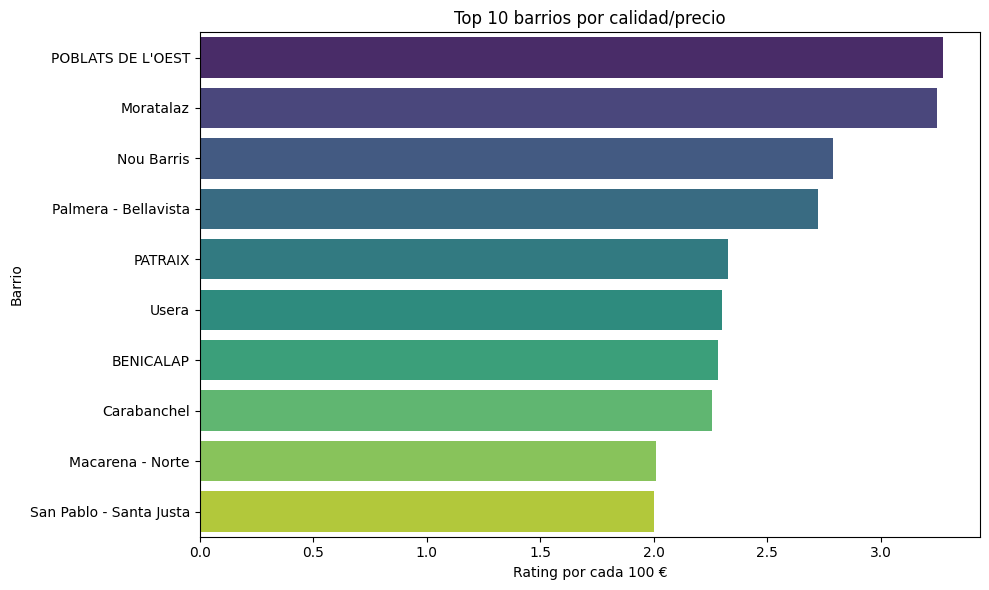

In [220]:
neighbourhood_quality = (
    df.groupby('neighbourhood_district')
      .agg(mean_price=('price','mean'),
           mean_rating=('review_scores_rating','mean'))
)

neighbourhood_quality['rating_per_100_eur'] = (
    neighbourhood_quality['mean_rating'] / (neighbourhood_quality['mean_price'] / 100)
)

# Top 10 barrios calidad/precio
neigh_top = neighbourhood_quality.sort_values('rating_per_100_eur', ascending=False).head(10)

# Gráfico de barras horizontal: rating_per_100_eur
plt.figure(figsize=(10,6))
sns.barplot(
    data=neigh_top.reset_index(),
    x='rating_per_100_eur',
    y='neighbourhood_district',
    palette='viridis'
)
plt.xlabel('Rating por cada 100 €')
plt.ylabel('Barrio')
plt.title('Top 10 barrios por calidad/precio')
plt.tight_layout()
plt.show()


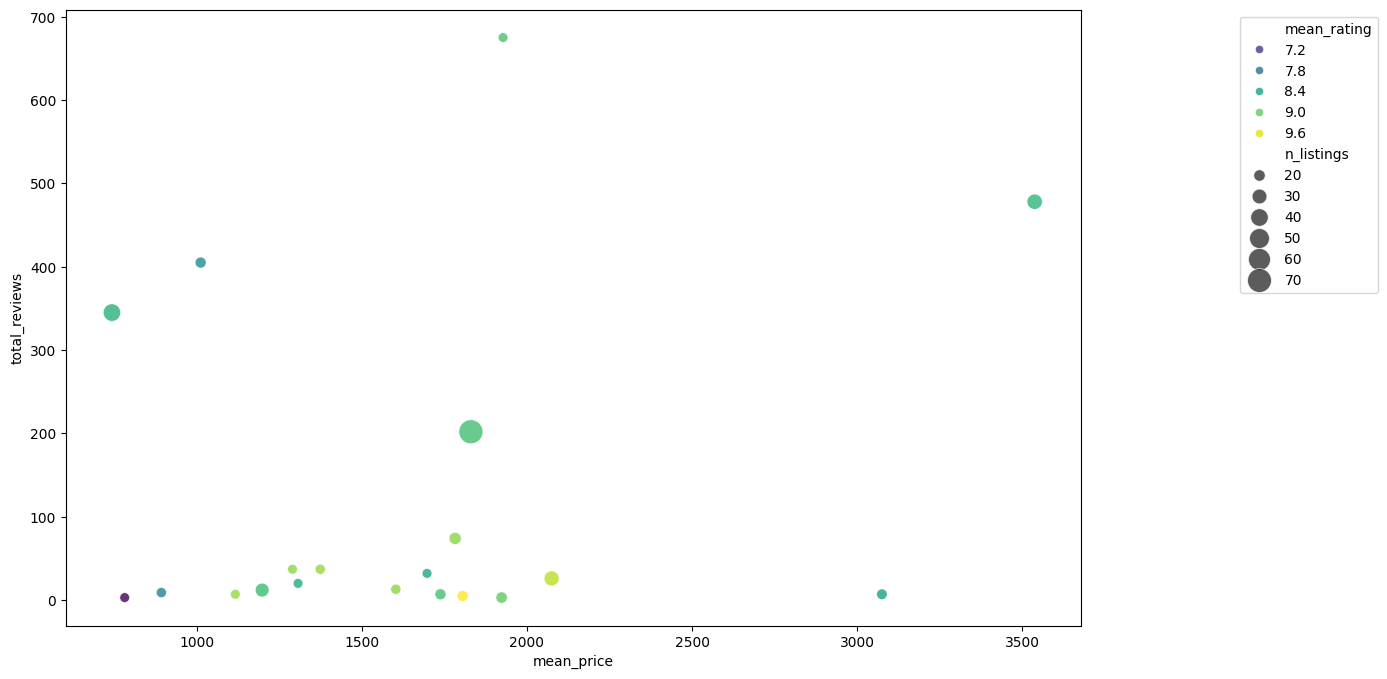

In [221]:
plt.figure(figsize=(14,8))
scatter = sns.scatterplot(
    data=host_stats.reset_index(),
    x='mean_price',
    y='total_reviews',
    size='n_listings',
    hue='mean_rating',
    palette='viridis',
    sizes=(50, 300),
    alpha=0.8
)

plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left')
plt.subplots_adjust(right=0.85)  # Deja espacio extra a la derecha
plt.show()
